# 🎬 Análise do Cinema Brasileiro e Estrangeiro (2009-2019)

Projeto final do curso de Técnicas de Programação.

## 📌 Sobre o dataset
Este dataset contém informações sobre filmes brasileiros e estrangeiros exibidos no Brasil entre 2009 e 2019, incluindo gênero, nacionalidade, distribuidora, público e renda.

## 🎯 Objetivos
1. Explorar e descrever os dados.
2. Realizar tratamento e limpeza.
3. Responder 5 perguntas de análise usando Pandas.

## 📂 Estrutura do notebook
1. Importação de bibliotecas
2. Carregamento e exploração inicial
3. Tratamento e qualidade dos dados
4. Análises e respostas às 5 perguntas
5. Conclusões

In [16]:
#Importando o Pandas
import pandas as pd

# Habilita a exibição dos gráficos dentro do notebook
%matplotlib inline

In [2]:
# Carregando o dataset de filmes
df = pd.read_csv('Listagem_dos_Filmes_Brasileiros_e_Estrangeiros_Exibidos_2009_a_2019.csv')
df.head()

,Unnamed: 0,Ano de exibição,Título da obra,Gênero,País(es) produtor(es) da obra,Nacionalidade da obra,Empresa distribuidora,Origem da empresa distribuidora,Público no ano de exibição,Renda (R$) no ano de exibição
0,0,2019,120 Batimentos Por Minuto,Ficção,França,Estrangeira,Imovision,Distribuição Nacional,10.0,70.0
1,1,2019,3 Faces,Ficção,Irã,Estrangeira,Imovision,Distribuição Nacional,6289.0,103805.0
2,2,2019,45 Dias Sem Você,Ficção,Brasil,Brasileira,O2 Play,Distribuição Nacional,3303.0,31295.0
3,3,2019,A 100 Passos De Um Sonho,Ficção,Estados Unidos,Estrangeira,Disney,Distribuição Internacional,69.0,4186.0
4,4,2019,A Abelhinha Maya - O Filme,Animação,Alemanha,Estrangeira,Playarte,Distribuição Nacional,402.0,3531.0


In [3]:
#Tamanho da tabela
df.shape

(7052, 10)

In [4]:
#Tipos de cada coluna e nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7052 entries, 0 to 7051
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       7052 non-null   int64  
 1   Ano de exibição                  7052 non-null   int64  
 2   Título da obra                   7052 non-null   object 
 3   Gênero                           7052 non-null   object 
 4   País(es) produtor(es) da obra    7052 non-null   object 
 5   Nacionalidade da obra            7052 non-null   object 
 6   Empresa distribuidora            7052 non-null   object 
 7   Origem da empresa distribuidora  7052 non-null   object 
 8   Público no ano de exibição       7052 non-null   float64
 9   Renda (R$) no ano de exibição    7052 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 551.1+ KB


In [13]:
# Verificando se existem linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [5]:
# Estatísticas das colunas numéricas
df.describe()

,Unnamed: 0,Ano de exibição,Público no ano de exibição,Renda (R$) no ano de exibição
count,7052.000000,7052.000000,7.052000e+03,7.052000e+03
mean,3536.842881,2014.344867,2.438021e+05,3.105320e+06
std,2042.750038,3.104598,9.412036e+05,1.282943e+07
min,0.000000,2009.000000,0.000000e+00,0.000000e+00
25%,1768.750000,2012.000000,3.470000e+02,3.021625e+03
50%,3531.500000,2015.000000,3.947500e+03,4.297715e+04
75%,5308.250000,2017.000000,4.491825e+04,5.779531e+05
max,7080.000000,2019.000000,1.965647e+07,3.386249e+08


In [6]:
# Quantos filmes têm público igual a zero?
(df['Público no ano de exibição'] == 0).sum()

np.int64(7)

In [7]:
# Filmes com público zero
df[df['Público no ano de exibição'] == 0]

,Unnamed: 0,Ano de exibição,Título da obra,Gênero,País(es) produtor(es) da obra,Nacionalidade da obra,Empresa distribuidora,Origem da empresa distribuidora,Público no ano de exibição,Renda (R$) no ano de exibição
808,814,2018,Blow-Up - Depois Daquele Beijo*,Ficção,"Estados Unidos, Itália, Reino Unido",Estrangeira,Zeta Filmes,Distribuição Nacional,0.0,0.0
843,849,2018,Colo*,Ficção,Portugal,Estrangeira,Zeta Filmes,Distribuição Nacional,0.0,0.0
856,862,2018,Coragem! As Muitas Vidas do Cardeal Dom Paulo ...,Documentário,Brasil,Brasileira,TV Meio Ambiente,Distribuição Nacional,0.0,0.0
990,996,2018,Jesus - A Esperança*,Ficção,Brasil,Brasileira,Moro Comunicação,Distribuição Nacional,0.0,0.0
1024,1030,2018,Macaco Tião - O Candidato do Povo*,Documentário,Brasil,Brasileira,Pipa Produções,Distribuição Nacional,0.0,0.0
1205,1211,2018,Pai em Dose Dupla 2*,Ficção,Estados Unidos,Estrangeira,Paramount,Distribuição Internacional,0.0,0.0
1275,1281,2018,Silêncio no Estúdio*,Documentário,Brasil,Brasileira,Modo Operante Produções,Distribuição Nacional,0.0,0.0


In [8]:
# Valores únicos nas colunas de texto
for coluna in ['Gênero', 'Nacionalidade da obra', 'Origem da empresa distribuidora']:
    print(f"\nColuna: {coluna}")
    print(df[coluna].value_counts())


Coluna: Gênero
Gênero
Ficção          5534
Documentário     967
Animação         510
Videomusical      41
Name: count, dtype: int64

Coluna: Nacionalidade da obra
Nacionalidade da obra
Estrangeira    4946
Brasileira     2106
Name: count, dtype: int64

Coluna: Origem da empresa distribuidora
Origem da empresa distribuidora
Distribuição Nacional                    5404
Distribuição Internacional               1627
Codistribuição Internacional-Nacional      21
Name: count, dtype: int64


## 🧹 Tratamento e Qualidade dos Dados

Nesta seção vamos:
- Remover a coluna `Unnamed: 0` (não traz informação).
- Renomear as colunas para nomes mais simples.
- Remover 7 filmes com público e renda iguais a zero (dados ausentes).
- Criar colunas novas úteis para a análise.

In [9]:
# Removendo a coluna Unnamed: 0 que não traz informação
df = df.drop(columns=['Unnamed: 0'])

# Conferindo o resultado
df.head()

,Ano de exibição,Título da obra,Gênero,País(es) produtor(es) da obra,Nacionalidade da obra,Empresa distribuidora,Origem da empresa distribuidora,Público no ano de exibição,Renda (R$) no ano de exibição
0,2019,120 Batimentos Por Minuto,Ficção,França,Estrangeira,Imovision,Distribuição Nacional,10.0,70.0
1,2019,3 Faces,Ficção,Irã,Estrangeira,Imovision,Distribuição Nacional,6289.0,103805.0
2,2019,45 Dias Sem Você,Ficção,Brasil,Brasileira,O2 Play,Distribuição Nacional,3303.0,31295.0
3,2019,A 100 Passos De Um Sonho,Ficção,Estados Unidos,Estrangeira,Disney,Distribuição Internacional,69.0,4186.0
4,2019,A Abelhinha Maya - O Filme,Animação,Alemanha,Estrangeira,Playarte,Distribuição Nacional,402.0,3531.0


In [10]:
# Renomeando as colunas para nomes mais simples
df = df.rename(columns={
    'Ano de exibição': 'ano',
    'Título da obra': 'titulo',
    'Gênero': 'genero',
    'País(es) produtor(es) da obra': 'paises_produtores',
    'Nacionalidade da obra': 'nacionalidade',
    'Empresa distribuidora': 'distribuidora',
    'Origem da empresa distribuidora': 'origem_distribuidora',
    'Público no ano de exibição': 'publico',
    'Renda (R$) no ano de exibição': 'renda'
})

df.head()

,ano,titulo,genero,paises_produtores,nacionalidade,distribuidora,origem_distribuidora,publico,renda
0,2019,120 Batimentos Por Minuto,Ficção,França,Estrangeira,Imovision,Distribuição Nacional,10.0,70.0
1,2019,3 Faces,Ficção,Irã,Estrangeira,Imovision,Distribuição Nacional,6289.0,103805.0
2,2019,45 Dias Sem Você,Ficção,Brasil,Brasileira,O2 Play,Distribuição Nacional,3303.0,31295.0
3,2019,A 100 Passos De Um Sonho,Ficção,Estados Unidos,Estrangeira,Disney,Distribuição Internacional,69.0,4186.0
4,2019,A Abelhinha Maya - O Filme,Animação,Alemanha,Estrangeira,Playarte,Distribuição Nacional,402.0,3531.0


In [11]:
# Removendo os filmes com público zero

# Antes da remoção: quantas linhas temos?
print(f"Antes: {df.shape[0]} linhas")

# Removendo filmes com público igual a zero
df = df[df['publico'] > 0]

# Depois da remoção
print(f"Depois: {df.shape[0]} linhas")

Antes: 7052 linhas
Depois: 7045 linhas


In [12]:
# Criando a coluna ticket_medio
df['ticket_medio'] = df['renda'] / df['publico']

# Conferindo o resultado
df[['titulo', 'publico', 'renda', 'ticket_medio']].head(10)

,titulo,publico,renda,ticket_medio
0,120 Batimentos Por Minuto,10.0,70.0,7.000000
1,3 Faces,6289.0,103805.0,16.505804
2,45 Dias Sem Você,3303.0,31295.0,9.474720
3,A 100 Passos De Um Sonho,69.0,4186.0,60.666667
4,A Abelhinha Maya - O Filme,402.0,3531.0,8.783582
5,A Batalha Das Correntes,19579.0,425304.0,21.722458
6,A Bela da Tarde,14.0,253.0,18.071429
7,A Cabeça De Gumercindo Saraiva,195.0,1830.0,9.384615
8,A Caminho De Casa,652641.0,9445705.0,14.473049
9,A Casa De Veraneio,8001.0,137759.0,17.217723


In [15]:
# Resumo final do dataset após o tratamento
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nNulos: {df.isnull().sum().sum()}")
print(f"\nDuplicatas: {df.duplicated().sum()}")

Dimensões: 7045 linhas × 10 colunas

Colunas: ['ano', 'titulo', 'genero', 'paises_produtores', 'nacionalidade', 'distribuidora', 'origem_distribuidora', 'publico', 'renda', 'ticket_medio']

Nulos: 0

Duplicatas: 0


## 📊 Análises e Respostas às 5 Perguntas

Nesta seção, vamos responder cinco perguntas sobre o dataset usando técnicas de filtragem, agrupamento e transformação no Pandas. Cada pergunta terá:
- Uma explicação do que queremos descobrir.
- O código da análise.
- A interpretação dos resultados.

### 🎬 Pergunta 1: Como evoluiu o público e a renda do cinema entre 2009 e 2019?

**Objetivo:** analisar a evolução anual do público total e da renda total no cinema brasileiro para identificar tendências ao longo da década.

**Técnica usada:** agrupamento com `groupby` e agregação com `sum`.

In [18]:
# Agrupando por ano e somando público e renda
evolucao_anual = df.groupby('ano')[['publico', 'renda']].sum()

# Formatando para exibição amigável
evolucao_anual_formatado = evolucao_anual.copy()
evolucao_anual_formatado['publico'] = evolucao_anual_formatado['publico'].apply(lambda x: f'{x:,.0f}'.replace(',', '.'))
evolucao_anual_formatado['renda'] = evolucao_anual_formatado['renda'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

evolucao_anual_formatado

,publico,renda
ano,,
2009,112.670.935,"R$ 969.796.083,34"
2010,134.836.791,"R$ 1.260.373.852,47"
2011,143.206.574,"R$ 1.449.997.621,20"
2012,146.598.376,"R$ 1.614.022.222,83"
2013,149.518.269,"R$ 1.753.200.571,82"
2014,155.612.992,"R$ 1.955.943.573,92"
2015,173.022.827,"R$ 2.351.590.807,12"
2016,184.327.360,"R$ 2.599.327.628,25"
2017,181.226.407,"R$ 2.717.664.734,85"


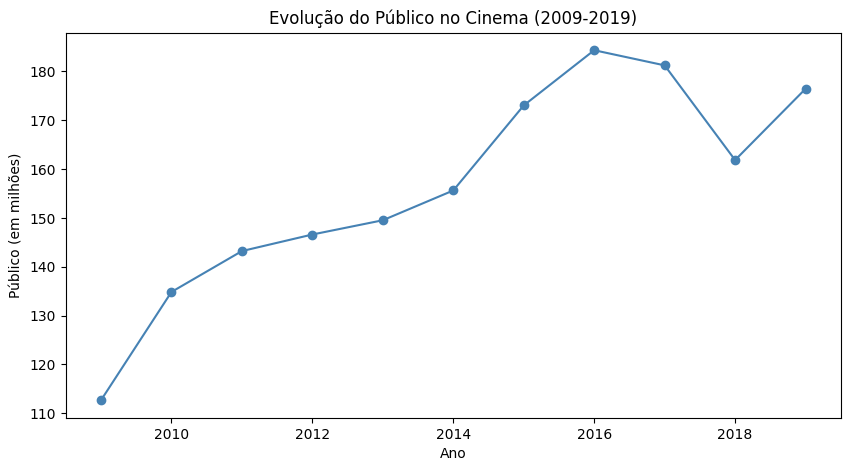

In [21]:
# Gráfico da evolução do público por ano (em milhões)
(evolucao_anual['publico'] / 1_000_000).plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    title='Evolução do Público no Cinema (2009-2019)',
    color='steelblue',
    ylabel='Público (em milhões)',
    xlabel='Ano'
);

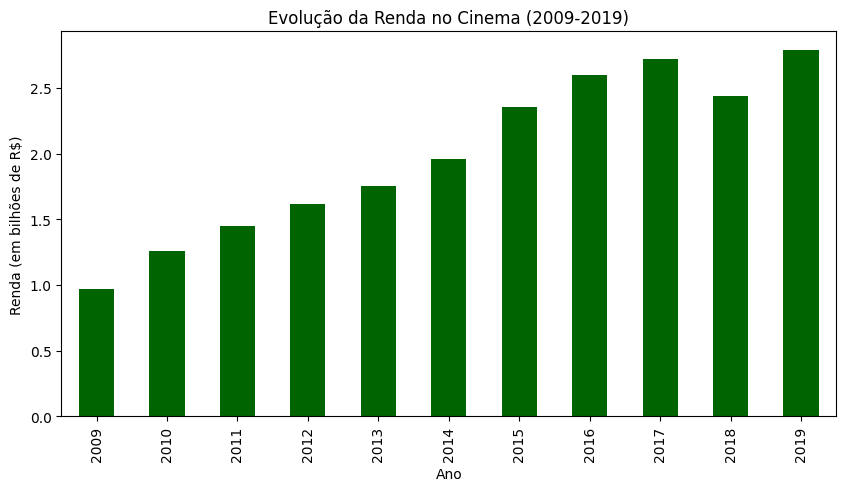

In [22]:
# Gráfico da evolução da renda por ano (em bilhões)
(evolucao_anual['renda'] / 1_000_000_000).plot(
    kind='bar',
    figsize=(10, 5),
    title='Evolução da Renda no Cinema (2009-2019)',
    color='darkgreen',
    ylabel='Renda (em bilhões de R$)',
    xlabel='Ano'
);

In [ ]:
# Calculando o crescimento percentual entre 2009 e 2019
publico_2009 = evolucao_anual.loc[2009, 'publico']
publico_2019 = evolucao_anual.loc[2019, 'publico']

renda_2009 = evolucao_anual.loc[2009, 'renda']
renda_2019 = evolucao_anual.loc[2019, 'renda']

crescimento_publico = ((publico_2019 - publico_2009) / publico_2009) * 100
crescimento_renda = ((renda_2019 - renda_2009) / renda_2009) * 100

print(f"Crescimento do público (2009 → 2019): {crescimento_publico:.1f}%")
print(f"Crescimento da renda (2009 → 2019): {crescimento_renda:.1f}%")

📈 Crescimento do público (2009 → 2019): 56.6%
💰 Crescimento da renda (2009 → 2019): 187.7%


#### 💡 Conclusões da Pergunta 1

- O **público total** cresceu **56,6%** entre 2009 e 2019, saindo de ~112 milhões para ~176 milhões de espectadores por ano.
- A **renda total** cresceu ainda mais: **187,7%** no mesmo período, passando de R$ 970 milhões para R$ 2,79 bilhões (quase triplicou).
- O **pico de público** foi em **2016** (~184 milhões) e o **pico de renda** foi em **2017** (~R$ 2,72 bilhões).
- Em **2018** o público caiu para ~162 milhões, mas a renda permaneceu alta (~R$ 2,43 bilhões) — indicando que o **valor médio do ingresso continuou subindo**.
- O descompasso entre o crescimento do público (56,6%) e o da renda (187,7%) sugere **aumento expressivo do preço médio do ingresso** ao longo da década.

### 🎬 Pergunta 2: Filmes brasileiros competem com os estrangeiros em público e bilheteria?

**Objetivo:** comparar o desempenho dos filmes brasileiros e estrangeiros em termos de público total, renda total e ticket médio.

**Técnica usada:** filtragem por condição e agrupamento com `groupby`.

In [28]:
# Agrupando por nacionalidade para comparar
comparacao_nacionalidade = df.groupby('nacionalidade').agg(
    total_filmes=('titulo', 'count'),
    publico_total=('publico', 'sum'),
    renda_total=('renda', 'sum'),
    ticket_medio=('ticket_medio', 'mean')
).round(2)

comparacao_nacionalidade

,total_filmes,publico_total,renda_total,ticket_medio
nacionalidade,,,,
Brasileira,2102,2.401161e+08,2.690876e+09,9.64
Estrangeira,4943,1.479177e+09,1.920784e+10,11.64


In [29]:
# Calculando a participação percentual de cada nacionalidade
total_publico_geral = df['publico'].sum()
total_renda_geral = df['renda'].sum()

for nacionalidade in ['Brasileira', 'Estrangeira']:
    publico_nac = df[df['nacionalidade'] == nacionalidade]['publico'].sum()
    renda_nac = df[df['nacionalidade'] == nacionalidade]['renda'].sum()
    print(f"\n{nacionalidade}:")
    print(f"   Participação no público: {(publico_nac / total_publico_geral) * 100:.1f}%")
    print(f"   Participação na renda:   {(renda_nac / total_renda_geral) * 100:.1f}%")


Brasileira:
   Participação no público: 14.0%
   Participação na renda:   12.3%

Estrangeira:
   Participação no público: 86.0%
   Participação na renda:   87.7%


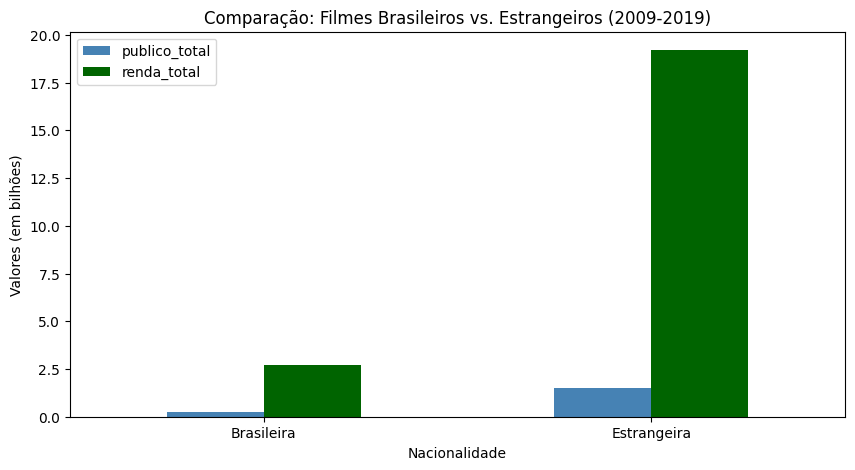

In [30]:
# Gráfico de barras comparando público e renda por nacionalidade
(comparacao_nacionalidade[['publico_total', 'renda_total']] / 1_000_000_000).plot(
    kind='bar',
    figsize=(10, 5),
    title='Comparação: Filmes Brasileiros vs. Estrangeiros (2009-2019)',
    color=['steelblue', 'darkgreen'],
    ylabel='Valores (em bilhões)',
    xlabel='Nacionalidade',
    rot=0
);

#### 💡 Conclusões da Pergunta 2

- Os filmes **estrangeiros dominam massivamente** o mercado brasileiro — eles representam a **grande maioria do público e da renda**.
- Apesar dos filmes **brasileiros representarem ~30% do catálogo** (2.106 de 7.045 filmes), eles captam uma **fatia muito menor** do público e da renda total.
- Isso mostra o desafio do cinema nacional: muita produção, mas **alcance comercial limitado** frente aos grandes estúdios internacionais.
- O **ticket médio** dos dois tipos tende a ser parecido — a diferença está no **volume**, não no preço cobrado.